# Cars 4 You: Expediting Car Evaluations with ML

This project addresses the challenge of predicting used car prices for a vehicle purchasing company. The main goal was to develop a robust machine learning pipeline that accurately estimates car values based on vehicle specifications, historical data, and market characteristics. We implemented a comprehensive approach starting with extensive data exploration to understand feature distributions and relationships, followed by systematic data cleaning to handle missing values, outliers, and inconsistent categorical entries.

Our methodology included feature engineering to create derived variables, and we employed a multi-strategy feature selection approach combining ANOVA F-test, Mutual Information, and RFE to identify the most predictive features. The modeling phase compared Random Forest and Ordinary Least Squares regression using k-fold cross-validation, with performance assessed through RMSE, MAE, R², and percentage error metrics.

The results demonstrated that our pipeline effectively captured the complex relationships influencing used car prices, with the Random Forest model showing superior performance in capturing non-linear patterns. The project delivers a production-ready pipeline capable of generating reliable price predictions for new vehicle listings, providing a valuable tool for automated evaluation in the used car market.
<br><br>

#### Group Member Contribution: <br>
Francisca Fernandes, 20250406 — Cleaning numerical variables, development of the model pipeline (33%)<br>
Maria Pimentel, 20250466 — Univariate and multivariate analysis, scaling, feature Selection (33%)<br>
Mariana Melo, 20250414 — Cleaning categorical data, feature selection (33%)<br><br>

## 1. Data Import & Exploratory Data Analysis

#### **1.1. Importing the Libraries and Dataset**


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge

In [32]:
train= pd.read_csv("train.csv").copy() #importing the dataset
test=pd.read_csv("test.csv").copy()

#### Initial Analysis**

The target variable `price` presents a right-skewed distribution, with the majority of cars concentrated in the lower price range and a long tail of high-value vehicles. This pattern is typical for used-car markets, where a small number of premium or nearly-new vehicles can reach disproportionately high prices.

1.5. Cross analysis

## Analyzing the categorical data 

From the visualizations above, we can see that the most frequent categories in each variable are valid and meaningful (car brands, fuel types, transmission types, etc.).
These observations provide a strong basis for defining the initial list of valid categories.
We will use the information from the graphs to identify the most frequent values for Brand, FuelType, and Transmission, as the distribution in Model is less clear and does not show a significant difference in frequency.

In [33]:
# Define the initial list of valid car brands
valid_brands = ['FORD', 'MERCEDES', 'VW', 'OPEL', 'BMW', 'AUDI', 'TOYOTA', 'SKODA', 'HYUNDAI']

# Fill missing Brand values with 'UNKNOWN'
train['Brand'] = train['Brand'].fillna('UNKNOWN') 

# Identify brands in the dataset that are not in the list of valid brands
invalids = sorted(
    [b for b in train['Brand'].unique() if b not in valid_brands],
    key=len
)

# Display the invalid brands found
print("Invalid brands:", invalids)

Invalid brands: ['w', 'V', 'W', 'v', 'MW', 'BM', 'pe', 'vw', 'or', 'mw', 'ud', 'FOR', 'ord', 'bmw', 'udi', 'Ope', 'pel', 'For', 'Aud', 'kod', 'for', 'aud', 'PEL', 'UDI', 'OPE', 'ORD', 'ope', 'AUD', 'Audi', 'Ford', 'Opel', 'opel', 'audi', 'koda', 'ford', 'Skod', 'SKOD', 'KODA', 'skod', 'Skoda', 'Toyot', 'skoda', 'oyota', 'yunda', 'OYOTA', 'TOYOT', 'toyot', 'Toyota', 'yundai', 'Hyunda', 'toyota', 'HYUNDA', 'ercede', 'hyunda', 'Hyundai', 'UNKNOWN', 'Mercede', 'hyundai', 'ercedes', 'mercede', 'ERCEDES', 'MERCEDE', 'Mercedes', 'mercedes']


This function automatically corrects invalid brand names that clearly match exactly one valid brand.
For each invalid value, if it appears as a substring of a single valid brand, it is replaced with that brand.
The function returns the updated dataframe, a dictionary of corrections applied, and a list of any remaining invalid brands that could not be corrected automatically.

In [34]:
def correct_invalid_brands_in_df(df, col, valid_brands, invalids):
    # Dictionary to store corrections applied
    corrections = {}
    
    for invalid in invalids:
        if invalid == 'UNKNOWN':
            continue  # Skip UNKNOWN values
        
        # Check if the invalid brand is contained in exactly one valid brand
        matches = [vb for vb in valid_brands if invalid in vb]
        
        if len(matches) == 1:
            valid = matches[0]
            df.loc[df[col] == invalid, col] = valid  # Replace invalid with the valid brand
            corrections[invalid] = valid

    # Identify any remaining invalid values that were not corrected
    remaining_invalids = [
        b for b in df[col].unique() 
        if b not in valid_brands and b not in corrections.keys()
    ]
    
    return df, corrections, remaining_invalids


In [35]:
# Apply corrections to invalid brands
train, corrections, remaining_invalids = correct_invalid_brands_in_df(
    train, 'Brand', valid_brands, invalids
)
# Show which corrections were made
print("Corrections applied:", corrections)

# Show any remaining invalid brands that could not be automatically corrected
print("Remaining invalid brands:", remaining_invalids)


Corrections applied: {'V': 'VW', 'MW': 'BMW', 'BM': 'BMW', 'FOR': 'FORD', 'PEL': 'OPEL', 'UDI': 'AUDI', 'OPE': 'OPEL', 'ORD': 'FORD', 'AUD': 'AUDI', 'SKOD': 'SKODA', 'KODA': 'SKODA', 'OYOTA': 'TOYOTA', 'TOYOT': 'TOYOTA', 'HYUNDA': 'HYUNDAI', 'ERCEDES': 'MERCEDES', 'MERCEDE': 'MERCEDES'}
Remaining invalid brands: ['Toyota', 'Audi', 'Ford', 'Skoda', 'Opel', 'Mercedes', 'mercedes', 'Hyundai', 'w', 'ord', 'bmw', 'UNKNOWN', 'yundai', 'Toyot', 'udi', 'Ope', 'opel', 'pel', 'For', 'pe', 'Mercede', 'audi', 'koda', 'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'ercedes', 'oyota', 'toyota', 'Skod', 'kod', 'v', 'for', 'aud', 'yunda', 'or', 'mw', 'mercede', 'ercede', 'ud', 'ope', 'hyunda', 'skod', 'toyot']


This function handles ambiguous or remaining invalid brand names that were not corrected in the first step. It uses contextual information such as the car’s Model and Year to decide the most likely correct brand. If a model is strongly associated with a single valid brand, that brand is assigned. If there is no clear match, the function falls back to the most frequent valid brand in the dataset. The function returns the updated dataframe, a dictionary of all corrections applied (including the context of model and year), and a list of any brands that still remain invalid.

In [36]:
def correct_ambiguous_brands(df, col, valid_brands, remaining_invalids, model_col='Model', year_col='Year'):
    corrections = {}
    past_replacements = {}

    # Identify the most common valid brand
    brand_freq = df[df[col].isin(valid_brands)][col].value_counts()
    most_common_brand = brand_freq.index[0] if not brand_freq.empty else None

    for invalid in remaining_invalids:
        subset = df[df[col] == invalid]
        for idx, row in subset.iterrows():
            model = row.get(model_col, None)
            year = row.get(year_col, None)
            original_brand = invalid

            # Case when model is unknown or missing
            if pd.isna(model) or str(model).strip().upper() == 'UNKNOWN':
                corrected = None
                if pd.notna(year):
                    year_subset = df[(df[year_col] == year) & (df[col].isin(valid_brands))]
                    if not year_subset.empty:
                        corrected = year_subset[col].mode()[0]

                if corrected is None:
                    corrected = most_common_brand

                df.at[idx, col] = corrected
                corrections[(invalid, model, year)] = corrected
                past_replacements[invalid] = corrected

            # Case when model is known
            else:
                model_rows = df[(df[model_col] == model) & (df[col].isin(valid_brands))]
                possible_brands = model_rows[col].value_counts()

                if len(possible_brands) == 1:
                    corrected = possible_brands.index[0]
                elif len(possible_brands) > 1:
                    corrected = possible_brands.index[0]
                else:
                    corrected = past_replacements.get(invalid, most_common_brand)

                df.at[idx, col] = corrected
                corrections[(invalid, model, year)] = corrected
                past_replacements[invalid] = corrected

            # Print final correction for this row
            if corrected == 'UNKNOWN':
                print(f"FINAL RESULT: '{original_brand}' (model='{model}', year='{year}') - remained 'UNKNOWN'")
            else:
                print(f"FINAL RESULT: '{original_brand}' (model='{model}', year='{year}') - corrected to '{corrected}'")

    # List remaining invalid brands
    still_invalid = [b for b in df[col].unique() if b not in valid_brands and b != 'UNKNOWN']
    return df, corrections, still_invalid


In [37]:
# Count how many 'UNKNOWN' values remain in the Brand column
unknown_count = train[train['Brand'] == 'UNKNOWN'].shape[0]
print(f"Count of 'UNKNOWN' in Brand: {unknown_count}")

# Get unique rows where Brand is UNKNOWN, sorted by model
unknown_pairs = (
    train[train['Brand'] == 'UNKNOWN']
    .drop_duplicates()
    .sort_values(by='model')
)

# Display the (Brand, Model) pairs where Brand is still UNKNOWN
print("\nPairs (Brand, Model) where Brand is UNKNOWN:")
display(unknown_pairs)


Count of 'UNKNOWN' in Brand: 1521

Pairs (Brand, Model) where Brand is UNKNOWN:


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
2045,14653,UNKNOWN,1 SERIES,2015.0,12498,Semi-Auto,14501.000000,Diesel,0.0,78.5,0.313407,54.0,4.0,0.0
32801,10388,UNKNOWN,1 Series,2018.0,17980,Manual,8067.000000,Petrol,145.0,52.3,1.500000,35.0,2.0,0.0
6475,14192,UNKNOWN,1 Series,2015.0,8869,Manual,62574.000000,Diesel,0.0,83.1,1.500000,74.0,2.0,0.0
74666,9516,UNKNOWN,1 Series,2017.0,16475,Manual,12194.000000,etrol,125.0,52.3,1.500000,60.0,1.0,0.0
63569,9669,UNKNOWN,1 Series,2018.0,22000,utomatic,101153.348285,Petrol,145.0,32.5,3.000000,31.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67565,31541,UNKNOWN,NaN,2014.0,9691,Automatic,29064.000000,Diesel,165.0,51.4,1.600000,31.0,2.0,0.0
68006,61305,UNKNOWN,NaN,2020.0,16999,Semi-Auto,10.000000,Petrol,145.0,44.1,1.200000,82.0,2.0,0.0
71703,13026,UNKNOWN,NaN,2014.0,15000,Semi-Auto,38689.000000,Petrol,235.0,37.7,3.000000,96.0,3.0,0.0
72025,68226,UNKNOWN,NaN,2017.0,10491,Manual,22211.000000,Petrol,150.0,60.1,1.200000,82.0,0.0,0.0


We can conclude that all invalid brand values have been resolved, as there are no more UNKNOWN entries remaining in the dataset.

#### Models

Here we will use the process of selecting the most frequent values again, but this time focusing on the car models. Since looking at all models at once does not provide a clear picture, we will visualize them by brand and define the most frequent models within each brand.

This function handles invalid or unknown car models in the dataset by applying a series of rules and heuristics to clean and standardize the model column. The process works as follows:

1. **Normalize the column** – missing values (NaN) are replaced with 'UNKNOWN', and all strings are stripped of whitespace and converted to uppercase for consistency.

2. **Identify invalid models** – any value in model that is not present in the valid_models_by_brand dictionary is considered invalid.

3. **Handle 'UNKNOWN' models** – for rows where the model is 'UNKNOWN', the function tries to infer the correct model by progressively matching combinations of Brand, Year, and fuelType with existing valid models. If no match is found, it uses the most frequent model for that brand as a fallback.

4. **Correct non-'UNKNOWN' invalid models** – for other invalid entries:

   * **Exact match priority:** If the invalid value exactly matches a valid model for the brand, it is immediately replaced by that model, ignoring any partial matches.
   * **Rule 1:** If the invalid value is contained in exactly one valid model for the brand, it is replaced by that model.
   * **Rule 2:** If the invalid value is not contained in any valid model, it is added as a new valid model for that brand.
   * **Rule 3:** If the invalid value could belong to multiple valid models, heuristics based on mpg, Year, and fuelType are applied to select the most likely model.

5. **Record corrections** – all replacements are tracked in a dictionary, mapping the original invalid value (or 'UNKNOWN') and row index to the corrected model.

The result is a cleaned model column where invalid, ambiguous, or partially matching entries are replaced with the most appropriate valid model based on brand, usage patterns, and contextual information, while giving priority to exact matches when they exist.


In [38]:
valid_models= {'FORD': ['FOCUS', 'FIESTA', 'KUGA', 'ECOSPORT', 'C-MAX', 'KA+', 'MANDEO' ],
'MERCEDES': ['C ClASS', 'A CLASS', 'E CLASS','GLC CLASS', 'GLA CLASS', 'B CLASS', 'CL CLASS', 'GLE CLASS'],
'VW': ['GOLF', 'POLO', 'TIGUAN', 'PASSAT', 'UP', 'T-ROC', 'TOUAREG', 'TOURAN', 'T-CROSS'],
'OPEL': ['CORSA', 'ASTRA', 'MOKKA X', 'INSIGNIA', 'MOKKA', 'CROSSLAND X', 'ZAFIRA', 'GRANDLAND X', 'ADAM', 'VIVA'],
'BMW': ['1 SERIES','2 SERIES','3 SERIES','4 SERIES','5 SERIES', 'X1', 'X3', 'X5', 'X2', 'X4', 'M4', '6 SERIES', 'Z4', 'X6', '7 SERIES', 'X7'],
'AUDI': ['A3', 'Q3', 'A4', 'A1', 'Q5', 'A5', 'Q2', 'A6', 'Q7', 'TT'],
'TOYOTA': ['YARIS', 'AYGO', 'AURIS', 'C-HR', 'RAV4', 'COROLLA', 'PRIUS', 'VERSO'],
'SKODA': ['FABIA', 'OCTAVIA', 'SUPERB', 'YETI OUTDOOR', 'CITIGO', 'KODIAQ', 'KAROQ', 'SCALA','KAMIQ', 'RAPID', 'YETI'],
'HYUNDAI': ['TUCSON', 'I10', 'I30', 'I20', 'KONA', 'IONIQ', 'SANTA FE', 'IX20', 'I40', 'IX35', 'I800']
}

In [39]:
def correct_invalid_models(df, valid_models_by_brand):
    """
    correct invalid or unknown values in the 'model' column using brand/context heuristics

    steps:
    1) normalize the 'model' column (strings, uppercase, no NaN)
    2) build a global set of all known valid models across brands
    3) identify which distinct model values in df are not in that valid set
    4) for each invalid value:
       - if it is 'UNKNOWN', try to infer a model using brand/year/fuelType context
       - otherwise, use brand-specific valid models and:
         a) fix simple substring typos when there is a unique match
         b) when there is no match, promote the value to a new valid model for that brand
         c) when there are multiple possible matches, pick one using mpg/year/fuelType heuristics
    5) return the updated dataframe and a dictionary describing all corrections applied
    """

    # Normalize 'model' column: fill NaN with 'UNKNOWN', strip spaces, convert to uppercase
    df['model'] = df['model'].fillna('UNKNOWN').astype(str).str.strip().str.upper()

    # Create a set of all valid models across brands
    all_valid_models = set(
        [m for models in valid_models_by_brand.values() for m in models]
    )

    # Identify invalid models (not in the global valid set) sorted by string length (descending)
    invalid_models = sorted(
        [m for m in df['model'].unique() if m not in all_valid_models],
        key=len,
        reverse=True
    )

    # dictionary to record every transformation applied
    corrections = {}

    # iterate over each distinct invalid model value
    for invalid in invalid_models:
        subset = df[df['model'] == invalid] # subset of rows where this specific invalid value appears in 'model'
        if subset.empty:
            # if there are no rows with this value anymore, skips to next invalid
            continue

        # Handle 'UNKNOWN' models with progressive contextual inference
        if invalid == 'UNKNOWN':
            # infer each unknown model individually using contextual information
            for idx, row in subset.iterrows():
                brand = row['Brand']
                year = row.get('year', None)
                fuel = row.get('fuelType', None)
                chosen = 'UNKNOWN'

                # define progressively weaker context combinations to search for similar rows
                combos = [
                    ('Brand', 'year', 'fuelType'),
                    ('Brand', 'year'),
                    ('Brand', 'fuelType')
                ]

                # try each context combination to infer the most likely model
                for combo in combos:
                    cond = True # will act as a boolean mask and refine it column by column
                    for c in combo:
                        # refine the boolean mask by requiring df[c] to match the current row's value in column c
                        cond = cond & (df[c] == row[c]) # boolean series 
                    # filter to rows with the same context but a known (non UNKNOWN) model
                    df_filtered = df[cond & (df['model'] != 'UNKNOWN')]
                    if not df_filtered.empty:
                        # choose the most frequent model among the matching rows
                        chosen = df_filtered['model'].mode()[0]
                        break

                # fallback: if no context-based inference worked, use most frequent model of the brand
                if chosen == 'UNKNOWN':
                    df_brand = df[(df['Brand'] == brand) & (df['model'] != 'UNKNOWN')]
                    if not df_brand.empty:
                        chosen = df_brand['model'].mode()[0]

                # write back the chosen model into the dataframe for this specific row
                df.at[idx, 'model'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen # record the correction with row index to distinguish per row decisions

            continue  # skip remaining logic for 'UNKNOWN' - it's already handled



        # From here onwards we handle NON 'UNKNOWN' invalid model values
        # infer the dominant brand associated with this invalid model (most frequent brand in subset)
        brand = subset['Brand'].mode()[0] if not subset.empty else 'UNKNOWN'
        brand_valids = set(valid_models_by_brand.get(brand, [])) # get the set of valid models for this brand

        # Exact match check: if invalid model is exactly a valid model, accept it
        if invalid in brand_valids:
            # no change is needed in the dataframe, but we still record it
            df.loc[df['model'] == invalid, 'model'] = invalid
            corrections[invalid] = invalid
            continue

        # Check for valid models that contain the invalid string as a substring
        matches = [vm for vm in brand_valids if invalid in vm]

        # case 1: invalid is contained in exactly one valid model - treats as a typo and replace
        if len(matches) == 1:
            valid = matches[0]
            # replace all occurrences of the invalid value with the inferred valid model
            df.loc[df['model'] == invalid, 'model'] = valid
            corrections[invalid] = valid
            continue

        # Case 2: invalid has no substring matches in known models for this brand
        # promote this previously unseen model as a new valid model for the brand
        elif len(matches) == 0:
            all_valid_models.add(invalid)
            valid_models_by_brand.setdefault(brand, []).append(invalid)
            corrections[invalid] = invalid
            continue

        # Case 3: invalid is contained in multiple valid models - ambiguity, resolve with heuristics
        elif len(matches) > 1:
            # resolve ambiguity row by row, since context (year, fuel, mpg) can differ per row
            for idx, row in subset.iterrows():
                brand = row['Brand']
                year = row.get('year', None)
                fuel = row.get('fuelType', None)
                mpg_value = row.get('mpg', None)

                # restrict candidate models to those valid for the specific row brand
                options = [m for m in matches if m in valid_models_by_brand.get(brand, [])]
                chosen = 'UNKNOWN'

                # if only one candidate remains at brand level, use it directly
                if len(options) == 1:
                    chosen = options[0]
                elif len(options) > 1:
                    # try to use mpg similarity: choose model whose average mpg is closest to row mpg
                    if pd.notna(mpg_value):
                        # compute mean mpg per candidate model
                        mpg_means = (
                            df[df['model'].isin(options)]
                            .groupby('model')['mpg']
                            .mean()
                            .dropna()
                            .to_dict()
                        )
                        if mpg_means:
                            # pick the model whose mean mpg is closest to the observed value
                            chosen = min(
                                mpg_means.keys(),
                                key=lambda m: abs(mpg_means[m] - mpg_value)
                            )

                    # if mpg did not resolve the ambiguity, fall back to year and fuelType filters
                    if chosen == 'UNKNOWN':
                        # progressively relax filters: (year, fuelType) -> year -> fuelType
                        for filters in [
                            ('year', 'fuelType'),
                            ('year',),
                            ('fuelType',)
                        ]:
                            # start with candidate models of the same brand and in options
                            cond = (df['Brand'] == brand) & (df['model'].isin(options))
                            # refine mask by matching each selected contextual column
                            for f in filters:
                                cond &= (df[f] == row.get(f, None))
                            df_filtered = df[cond]
                            if not df_filtered.empty:
                                # choose the most frequent model among matching rows
                                chosen = df_filtered['model'].mode()[0]
                                break

                # write back the chosen model into the dataframe for this specific row
                df.at[idx, 'model'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen # record the correction with row index


    return df, corrections


At the end of the model correction process, we still have two NaN values in the model column. We haven’t investigated the cause yet, and will need to check this in more detail later.

#### FuelType

This function standardizes and corrects invalid or unknown values in the fuelType column using a series of contextual rules:

1. **Normalization** – missing values are replaced with 'UNKNOWN' and all strings in fuelType, Brand, model, and transmission are uppercased and stripped of whitespace.

2. **Identify invalid values** – any fuel type not in the predefined list of valid fuel types is considered invalid.

3. **Correction rules**:

   * **Rule 1:** If the invalid value is contained in exactly one valid fuel type, it is replaced directly with that valid type.
   * **Rule 2:** If the invalid value does not match any valid fuel type, it is added as a new valid value.
   * **Rule 3:** If the invalid value could match multiple valid fuel types, the function uses the Brand and model to infer the most likely fuel type.
   * **Rule 4:** For 'UNKNOWN' values, the function progressively infers the fuel type using contextual information:

     * Brand + Model + Transmission
     * Brand + Model
     * Fallback to the most frequent fuel type for that brand

4. **Tracking corrections** – all replacements are stored in a dictionary mapping the original invalid value (or 'UNKNOWN') and row index to the corrected value.

The result is a cleaned fuelType column where all ambiguous or invalid entries are replaced with the most appropriate valid fuel type based on context.


In [ ]:
valid_fueltypes = ['PETROL', 'DIESEL', 'HYBRID']

def correct_invalid_fueltypes(df, valid_fueltypes):

    df = df.copy()
    
    # Normalize relevant columns
    df['fuelType'] = df['fuelType'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['Brand'] = df['Brand'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['model'] = df['model'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['transmission'] = df['transmission'].fillna('UNKNOWN').astype(str).str.strip().str.upper()

    valid_fueltypes = [f.upper().strip() for f in valid_fueltypes]
    all_valids = set(valid_fueltypes)

    # Identify invalid fuel types
    invalid_fuels = sorted(
        [f for f in df['fuelType'].unique() if f not in all_valids],
        key=len,
        reverse=True
    )

    corrections = {}

    for invalid in invalid_fuels:
        subset = df[df['fuelType'] == invalid]
        if subset.empty:
            continue

        # Find valid matches that contain the invalid string
        matches = [v for v in valid_fueltypes if invalid in v]

        # Rule 1: replace if matches exactly one valid fuel
        if len(matches) == 1:
            valid = matches[0]
            df.loc[df['fuelType'] == invalid, 'fuelType'] = valid
            corrections[invalid] = valid
            continue

        # Rule 2: add as new valid if not matched
        elif len(matches) == 0 and invalid != 'UNKNOWN':
            all_valids.add(invalid)
            valid_fueltypes.append(invalid)
            corrections[invalid] = invalid
            continue

        # Rule 3: resolve using Brand + Model context if multiple matches
        elif len(matches) > 1:
            for idx, row in subset.iterrows():
                brand = row['Brand']
                model = row['model']
                chosen = 'UNKNOWN'

                # Skip if no context is available
                if brand == 'UNKNOWN' and model == 'UNKNOWN':
                    corrections[f"{invalid}_{idx}"] = chosen
                    continue

                # Filter by Brand and Model
                cond = (
                    (df['Brand'] == brand) &
                    (df['model'] == model) &
                    (df['fuelType'].isin(matches))
                )
                df_filtered = df[cond & (df['fuelType'] != 'UNKNOWN')]

                # Pick the most frequent fuel type in the subset
                if not df_filtered.empty:
                    chosen = df_filtered['fuelType'].mode()[0]

                df.at[idx, 'fuelType'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen

        # Rule 4: progressively infer UNKNOWN fuel types
        elif invalid == 'UNKNOWN':
            for idx, row in subset.iterrows():
                brand = row['Brand']
                model = row['model']
                transmission = row['transmission']
                chosen = 'UNKNOWN'

                # a) Brand + Model + Transmission
                cond = (
                    (df['Brand'] == brand) &
                    (df['model'] == model) &
                    (df['transmission'] == transmission) &
                    (df['fuelType'] != 'UNKNOWN')
                )
                df_filtered = df[cond]

                if not df_filtered.empty:
                    chosen = df_filtered['fuelType'].mode()[0]
                else:
                    # b) Brand + Model
                    cond = (
                        (df['Brand'] == brand) &
                        (df['model'] == model) &
                        (df['fuelType'] != 'UNKNOWN')
                    )
                    df_filtered = df[cond]
                    if not df_filtered.empty:
                        chosen = df_filtered['fuelType'].mode()[0]
                    else:
                        # fallback: most frequent fuel type for the brand
                        df_brand = df[(df['Brand'] == brand) & (df['fuelType'] != 'UNKNOWN')]
                        if not df_brand.empty:
                            chosen = df_brand['fuelType'].mode()[0]

                df.at[idx, 'fuelType'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen

    return df, corrections

In [41]:
# train, fuel_corrections = correct_invalid_fueltypes(train, valid_fueltypes)


#### Transmission 

This function standardizes and corrects invalid or unknown values in the transmission column using a set of hierarchical rules:

1. **Normalization** – missing values are replaced with 'UNKNOWN' and all strings in transmission, Brand, model, and fuelType are uppercased and stripped of whitespace.

2. **Identify invalid values** – any transmission type not in the predefined list of valid transmissions is considered invalid.

3. **Correction rules**:

   * **Rule 1:** If an invalid value matches exactly one valid transmission, it is replaced directly.
   * **Rule 2:** If an invalid value does not match any valid transmission, it is added as a new valid transmission.
   * **Rule 3:** If an invalid value could match multiple valid transmissions, the function uses the context of Brand + Model + FuelType to select the most likely transmission.
   * **Rule 4:** For 'UNKNOWN' values, the function infers the transmission using the same context (Brand + Model + FuelType), and if no match is found, it falls back to the most frequent valid transmission overall.

4. **Tracking corrections** – all replacements are recorded in a dictionary mapping the original invalid value (or 'UNKNOWN') and row index to the corrected transmission.


In [42]:
valid_transmissions = ['MANUAL', 'AUTOMATIC', 'SEMI-AUTO']

def correct_invalid_transmissions(df, valid_transmissions):
    # Copy dataframe and normalize relevant columns
    df = df.copy()
    df['transmission'] = df['transmission'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['Brand'] = df['Brand'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['model'] = df['model'].fillna('UNKNOWN').astype(str).str.strip().str.upper()
    df['fuelType'] = df['fuelType'].fillna('UNKNOWN').astype(str).str.strip().str.upper()

    valid_transmissions = [t.upper().strip() for t in valid_transmissions]
    all_valids = set(valid_transmissions)

    # Identify invalid transmissions in dataset
    invalid_trans = sorted(
        [t for t in df['transmission'].unique() if t not in all_valids],
        key=len,
        reverse=True
    )

    corrections = {}

    for invalid in invalid_trans:
        subset = df[df['transmission'] == invalid]
        if subset.empty:
            continue

        is_unknown = invalid in 'UNKNOWN'
        matches = [v for v in valid_transmissions if invalid in v]

        # Rule 1: if contained in exactly 1 valid transmission → replace
        if len(matches) == 1 and not is_unknown:
            valid = matches[0]
            df.loc[df['transmission'] == invalid, 'transmission'] = valid
            corrections[invalid] = valid
            continue

        # Rule 2: if not contained in any valid transmission → add as new valid
        elif len(matches) == 0 and not is_unknown:
            all_valids.add(invalid)
            valid_transmissions.append(invalid)
            corrections[invalid] = invalid
            continue

        # Rule 3: if contained in multiple → use Brand + Model + FuelType for context
        elif len(matches) > 1 and not is_unknown:
            for idx, row in subset.iterrows():
                brand = row['Brand']
                model = row['model']
                fuel = row['fuelType']
                chosen = 'UNKNOWN'

                # If no context is available, keep as UNKNOWN
                if brand == 'UNKNOWN' and model == 'UNKNOWN' and fuel == 'UNKNOWN':
                    corrections[f"{invalid}_{idx}"] = chosen
                    continue

                # Filter dataset based on context and valid options
                cond = (
                    (df['Brand'] == brand) &
                    (df['model'] == model) &
                    (df['fuelType'] == fuel) &
                    (df['transmission'].isin(matches))
                )
                df_filtered = df[cond & (df['transmission'] != 'UNKNOWN')]

                if not df_filtered.empty:
                    chosen = df_filtered['transmission'].mode()[0]

                df.at[idx, 'transmission'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen

        # Rule 4: UNKNOWN - infer using context or fallback to most frequent globally
        elif is_unknown:
            for idx, row in subset.iterrows():
                brand = row['Brand']
                model = row['model']
                fuel = row['fuelType']
                chosen = 'UNKNOWN'

                # Try to infer from available context
                if brand != 'UNKNOWN' or model != 'UNKNOWN' or fuel != 'UNKNOWN':
                    cond = (
                        (df['Brand'] == brand) &
                        (df['model'] == model) &
                        (df['fuelType'] == fuel) &
                        (df['transmission'].isin(valid_transmissions))
                    )
                    df_filtered = df[cond & (~df['transmission'].str.contains("UNKNOWN"))]

                    if not df_filtered.empty:
                        chosen = df_filtered['transmission'].mode()[0]
                    else:
                        # Fallback: most frequent transmission overall
                        trans_freq = df[df['transmission'].isin(valid_transmissions)]['transmission'].value_counts()
                        if not trans_freq.empty:
                            chosen = trans_freq.index[0]

                df.at[idx, 'transmission'] = chosen
                corrections[f"{invalid}_{idx}"] = chosen

    return df, corrections


#### **Missing Values**

In [43]:

print(train.duplicated().sum())


0


In [44]:
def preprocess_year(train_df, test_df, max_valid_year=2020):
    """
    - capping years above max_valid_year to max_valid_year
    - flooring years to nearest integer
    - imputing missing years with model median, or global median if model median not available
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['year'] = pd.to_numeric(train_df['year'], errors='coerce') # coercion to numeric
    train_df.loc[train_df['year'] > max_valid_year, 'year'] = max_valid_year # Capping
    train_df['year'] = np.floor(train_df['year']) # Flooring

    # median calculations based on train_df
    global_median = train_df['year'].median()
    model_median_map = train_df.groupby('model')['year'].median()
    # Imputation in train_df
    train_df['year'] = train_df['year'].fillna(train_df['model'].map(model_median_map))
    train_df['year'] = train_df['year'].fillna(global_median)

    
    #same transformations for test_df
    test_df['year'] = pd.to_numeric(test_df['year'], errors='coerce')
    test_df.loc[test_df['year'] > max_valid_year, 'year'] = max_valid_year
    test_df['year'] = np.floor(test_df['year'])
    test_df['year'] = test_df['year'].fillna(test_df['model'].map(model_median_map))
    test_df['year'] = test_df['year'].fillna(global_median)

    return train_df, test_df

In [45]:
def drop_hasDamage(train_df, test_df):
    """
    Removes the 'hasDamage' column from both train and test dataframes.
    Uses erros='ignore' to avoid errors in case the column has already
    """
    
    cols_to_drop = ["hasDamage"]
    
    train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
    test_df = test_df.drop(columns=cols_to_drop, errors='ignore')
    
    return train_df, test_df

## 2.2.3. `Previous owners` column

In [46]:
def preprocess_previousOwners(train_df, test_df):
    """

    This function relies on 'year' and 'mileage' being preprocessed beforehand.


    Stages:
    - preivousOwners to numeric
    - negative become absolute (.abs()).
    - rounded to nearest integer (.round()).
    - zero imprecision correction: if (year > 2 OU km > 15k) AND (owners == 0) -> change owners to 1.
    - Calculate median and replace nans 
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    
    max_year = train_df['year'].max() 

    train_df['previousOwners'] = pd.to_numeric(train_df['previousOwners'], errors='coerce')
    train_df['previousOwners'] = train_df['previousOwners'].abs()
    train_df['previousOwners'] = train_df['previousOwners'].round()

    inac_own_condition_train = (
        ((max_year - train_df['year']) > 2) |
        (train_df['mileage'] > 15000)
    ) & (train_df['previousOwners'] == 0)
    
    train_df.loc[inac_own_condition_train, 'previousOwners'] = 1

    imputation_mean = train_df['previousOwners'].mean()

    train_df['previousOwners'] = train_df['previousOwners'].fillna(imputation_mean)

    # Same transformations for test_df
    test_df['previousOwners'] = pd.to_numeric(test_df['previousOwners'], errors='coerce')
    test_df['previousOwners'] = test_df['previousOwners'].abs()
    test_df['previousOwners'] = test_df['previousOwners'].round()

    inac_own_condition_test = (
        ((max_year - test_df['year']) > 2) |
        (test_df['mileage'] > 15000)
    ) & (test_df['previousOwners'] == 0)
    
    test_df.loc[inac_own_condition_test, 'previousOwners'] = 1

    test_df['previousOwners'] = test_df['previousOwners'].fillna(imputation_mean)
    
    return train_df, test_df

- We also found entries of cars with 0 previous owners, which, at first, did not seem reasonable. However, upon further thinking, the value 0 could indicate that the car was used in dealerships for test drives, which are usually not marketed as used cars (in the conventional way).
- Since these company cars are essentially new, they should not be older than 2 years or have over 15 000 miles (these ceiling values were defined after group discussion and broad search, rather than based on a concrete source).
- If the cars do not comply with these conditions, it's likely a typo or a user registering their car as having 0 owners before themselves, for instance. Therefore, those values were replaced with 1.

## 2.2.4. `paintQuality%` column

- We did not find negative values, however we found percentages over 100. We decided to truncate values exceeding 100% to 100%. We chose to keep values with decimal places.
- Missing values where replaced with the mean value, because the dataset did not contain outliers. 

In [47]:
def preprocess_paintQuality(train_df, test_df):
    """
    paintQuality% preprocessing:
    - Convert to numeric, coerce errors
    - Negative values to absolute
    - Cap values at 100
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['paintQuality%'] = pd.to_numeric(train_df['paintQuality%'], errors='coerce')
    train_df['paintQuality%'] = train_df['paintQuality%'].abs()
    train_df['paintQuality%'] = train_df['paintQuality%'].clip(upper=100)
    imputation_median = train_df['paintQuality%'].median()
    train_df['paintQuality%'] = train_df['paintQuality%'].fillna(imputation_median)
    
    # for test 
    test_df['paintQuality%'] = pd.to_numeric(test_df['paintQuality%'], errors='coerce')
    test_df['paintQuality%'] = test_df['paintQuality%'].abs()
    test_df['paintQuality%'] = test_df['paintQuality%'].clip(upper=100)
    test_df['paintQuality%'] = test_df['paintQuality%'].fillna(imputation_median)
    
    return train_df, test_df

## 2.2.5. `mileage%` column

In [48]:
def preprocess_mileage(train_df, test_df):
    """
    'mileage' preprocessing for train and test dataframes:
    Steps:
    1. Convert 'mileage' to numeric (errors='coerce' turns invalid values into NaN)
    2. Convert negative values to absolute
    3. Calculate the median (imputation value) FROM THE TRAIN_DF
    4. Impute NaNs in train_df with the median
    5. Impute NaNs in test_df with the median (calculated from train_df)
    """

    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['mileage'] = pd.to_numeric(train_df['mileage'], errors='coerce')
    train_df['mileage'] = train_df['mileage'].abs()

    imputation_median = train_df['mileage'].median()
    train_df['mileage'] = train_df['mileage'].fillna(imputation_median)

    test_df['mileage'] = pd.to_numeric(test_df['mileage'], errors='coerce')
    test_df['mileage'] = test_df['mileage'].abs()
    test_df['mileage'] = test_df['mileage'].fillna(imputation_median)
    
    return train_df, test_df

## 2.2.6. `tax` column

In [49]:
def preprocess_tax(train_df, test_df):
    """
    Cleans and imputes the 'tax' column for both train and test dataframes.

    Steps:
    - Converts 'tax' to numeric (errors='coerce' turns invalid values into NaN).
    - Converts negative values to absolute.
    - Calculates the median (imputation value) FROM train_df.
    - Imputes NaNs in train_df with the median.
    - Imputes NaNs in test_df with the median (learned from train_df).
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

   
    train_df['tax'] = pd.to_numeric(train_df['tax'], errors='coerce')
    train_df['tax'] = train_df['tax'].abs()

    imputation_median = train_df['tax'].median()

   
    train_df['tax'] = train_df['tax'].fillna(imputation_median)


    test_df['tax'] = pd.to_numeric(test_df['tax'], errors='coerce')
    test_df['tax'] = test_df['tax'].abs()
    test_df['tax'] = test_df['tax'].fillna(imputation_median)
    
    return train_df, test_df

## 2.2.7. `mpg` column

In [50]:
def preprocess_mpg(train_df, test_df):
    """
    Cleans and imputes the 'mpg' column for the train and test dataframes.

    The imputation logic (median) is LEARNED from train_df and APPLIED
    to both (train_df and test_df).

    Steps (following the order of the original script):
    1. Converts 'mpg' to numeric (errors='coerce').
    2. Converts negative values to absolute.
    3. Calculates the median (imputation value) FROM train_df (after abs).
    4. Imputes NaNs in both dataframes with the train median.
    5. "Caps" (clips) the values in both dataframes between 10 and 200.
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['mpg'] = pd.to_numeric(train_df['mpg'], errors='coerce')
    train_df['mpg'] = train_df['mpg'].abs()
    imputation_median = train_df['mpg'].median()
    train_df['mpg'] = train_df['mpg'].fillna(imputation_median)
    train_df['mpg'] = train_df['mpg'].clip(lower=10, upper=200)

    # test_df     
    test_df['mpg'] = pd.to_numeric(test_df['mpg'], errors='coerce')
    test_df['mpg'] = test_df['mpg'].abs()
    test_df['mpg'] = test_df['mpg'].fillna(imputation_median)
    test_df['mpg'] = test_df['mpg'].clip(lower=10, upper=200)
    
    return train_df, test_df

## 2.2.8. `engineSize` column

In [51]:
def preprocess_engineSize(train_df, test_df):
    """
    Cleans and imputes the 'engineSize' column for the train and test dataframes.

    The imputation logic (median) is LEARNED from train_df and APPLIED
    to both (train_df and test_df).

    Steps:
    1. Converts 'engineSize' to numeric (errors='coerce').
    2. Converts negative values to absolute.
    3. Replaces '0' values with NaN, so they can be imputed.
    4. Calculates the median (imputation value) FROM train_df.
    5. Imputes NaNs in train_df with the median.
    6. Imputes NaNs in test_df with the median (learned from train_df).
    """
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    
    train_df['engineSize'] = pd.to_numeric(train_df['engineSize'], errors='coerce')
    train_df['engineSize'] = train_df['engineSize'].abs()
    train_df.loc[train_df['engineSize'] == 0, 'engineSize'] = np.nan #  0 as NaN

    imputation_median = train_df['engineSize'].median()

    
    train_df['engineSize'] = train_df['engineSize'].fillna(imputation_median)

    # test df
    test_df['engineSize'] = pd.to_numeric(test_df['engineSize'], errors='coerce')
    test_df['engineSize'] = test_df['engineSize'].abs()
    test_df.loc[test_df['engineSize'] == 0, 'engineSize'] = np.nan # Tratar 0 como NaN
    test_df['engineSize'] = test_df['engineSize'].fillna(imputation_median)
    
    return train_df, test_df

In this section we will analyse
\[
\begin{aligned}
\text{year} &\in [1900, 2020] \\[6pt]
\text{mileage} &\geq 0 \\[6pt]
\text{tax} &\geq 0 \\[6pt]
\text{mpg} &> 0 \\[6pt]
\text{engineSize} &> 0 \\[6pt]
\text{paintQuality\%} &\in [0, 100] \\[6pt]
\text{previousOwners} &\in \mathbb{N}_0 = \{0, 1, 2, \dots\} \\[6pt]
\text{hasDamage} &\in \{0, 1\}
\end{aligned}
\]

<b>Interpretation</b>: <br>
These scatterplots show how pairs of predictors interact to influence `price`. Each point represents a car, and the color scale (from dark to bright) indicates increasing price.<br>

- <b>Year vs Mileage</b>: Clear depreciation pattern (newer cars with low mileage cluster are in the high-price region, and older cars or those with higher mileage tend to have much lower prices).<br>

- <b>Engine Size vs mpg</b>: Inverse relationship between engine size and fuel efficiency. However, higher prices concentrate around larger engines with low mpg, reflecting performance and luxury vehicles.<br>

- <b>Engine Size vs Tax</b>: Positive interaction - larger engines generally lead to higher tax costs and, at the same time, correspond to higher prices. This aligns with regulatory and market behavior for high-performance cars.<br>

- <b>Paint Quality% vs Previous Owners</b>: There appears to be no relationship between these 2 variables, and no correlation with price whatsoever.

### 1.7. Scaling the data

Why scale the data? <br>
- Make features comparable: If mileage is ~10^5 and engineSize is ~1–6, unscaled linear models will "overweight" big-magnitude columns by default.

- Regularization fairness: Ridge/Lasso "shrink" coefficients assuming features are on similar scales; unscaled data biases which features get shrunk.

- Distance & kernels: KNN, SVM and PCA literally depend on distances/variances, so we HAVE to scale the data.

<br>

So, what kinds of scales should we use? <br>

- StandardScaler (zero mean, unit variance): Good when a feature is roughly symmetric or well-behaved after cleaning/engineering. Great default for linear/SVM/NN. Will apply this standardization to `car_age`, `engineSize`, and `mpg`.

- RobustScaler (median/IQR): Better when outliers remain (heavy tails) and we don’t want them to dominate. Will apply RobustScaler to `mileage`, `tax`, `miles_per_year`, `efficiency_ratio`, `tax_per_engine`.

- MinMaxScaler (0–1): Good for naturally bounded features or when a model expects bounded inputs; sensitive to outliers. Must use this scale for `paintQuality%` (0–100 turns into 0–1), `previousOwners` and `condition_score` due to being a small-range count.

For now, we won't scale the categorical variables (already one-hot) or the target (price), because keeping it in original units is better for interpretability unless we end up choosing a log-target modeling strategy.

In [52]:
#   StandardScaler: car_age, engineSize, mpg
#   RobustScaler: mileage, tax, miles_per_year, efficiency_ratio, tax_per_engine
#   MinMaxScaler: paintQuality%, previousOwners, condition_score
#   (car_age_bin is categorical: don't scale)

def scale_all_features(train_df, test_df=None):
    trainX = train_df.copy()
    testX  = test_df.copy() if isinstance(test, pd.DataFrame) else None

    std_cols = [c for c in ['car_age','engineSize','mpg'] if c in trainX.columns]
    rob_cols = [c for c in ['mileage','tax','miles_per_year','efficiency_ratio','tax_per_engine'] if c in trainX.columns]
    mm_cols  = [c for c in ['paintQuality%','previousOwners','condition_score'] if c in trainX.columns]

    scalers = {}

    # Standard
    if std_cols:
        ss = StandardScaler().fit(trainX[std_cols])
        scalers['standard'] = (std_cols, ss)
        trainX[[f'{c}_sc' for c in std_cols]] = ss.transform(trainX[std_cols])
        if testX is not None:
            testX[[f'{c}_sc' for c in std_cols]]  = ss.transform(testX[std_cols])

    # Robust
    if rob_cols:
        rs = RobustScaler().fit(trainX[rob_cols])
        scalers['robust'] = (rob_cols, rs)
        trainX[[f'{c}_sc' for c in rob_cols]] = rs.transform(trainX[rob_cols])
        if testX is not None:
            testX[[f'{c}_sc' for c in rob_cols]]  = rs.transform(testX[rob_cols])

    # MinMax (0–1)
    if mm_cols:
        mms = MinMaxScaler().fit(trainX[mm_cols])
        scalers['minmax'] = (mm_cols, mms)
        trainX[[f'{c}_sc' for c in mm_cols]] = mms.transform(trainX[mm_cols])
        if testX is not None:
            testX[[f'{c}_sc' for c in mm_cols]]  = mms.transform(testX[mm_cols])

    return trainX, testX, scalers

train_sc, test_sc, scalers = scale_all_features(train_fe, test_fe)

print("Scaled columns appended:", [c for c in train_sc.columns if c.endswith('_sc')][:12], "…")

Scaled columns appended: ['car_age_sc', 'engineSize_sc', 'mpg_sc', 'mileage_sc', 'tax_sc', 'miles_per_year_sc', 'efficiency_ratio_sc', 'tax_per_engine_sc', 'paintQuality%_sc', 'previousOwners_sc', 'condition_score_sc'] …


In [53]:
train_sc.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,...,engineSize_sc,mpg_sc,mileage_sc,tax_sc,miles_per_year_sc,efficiency_ratio_sc,tax_per_engine_sc,paintQuality%_sc,previousOwners_sc,condition_score_sc
0,69512,VW,GOLF,2016.0,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,...,0.592657,-2.650997,0.444764,NaN,0.328540,-1.336552,NaN,0.495026,0.737521,0.490541
1,53000,TOYOTA,YARIS,2019.0,13790,MANUAL,4589.0,PETROL,145.0,47.900000,...,-0.279247,-0.439616,-0.508354,0.0,-0.584812,-0.082115,0.392241,0.390149,0.388847,0.546449
2,6366,AUDI,Q2,2019.0,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,...,-0.279247,-0.863918,-0.546947,0.0,-0.651715,-0.305341,0.392241,0.438554,0.737521,0.484228
3,29021,FORD,FIESTA,2018.0,12500,MANUAL,9102.0,PETROL,145.0,65.700000,...,-1.151151,0.639321,-0.327864,0.0,-0.377102,1.533085,1.267241,0.390149,0.000621,0.265534
4,10062,BMW,2 SERIES,2019.0,22995,MANUAL,1000.0,PETROL,145.0,42.800000,...,-0.279247,-0.748750,-0.651889,0.0,-0.833635,-0.244752,0.392241,0.769318,0.621297,0.543067


In [54]:
train = train_sc.copy()

#### Visualization of the scaled features (and comparison with originals)

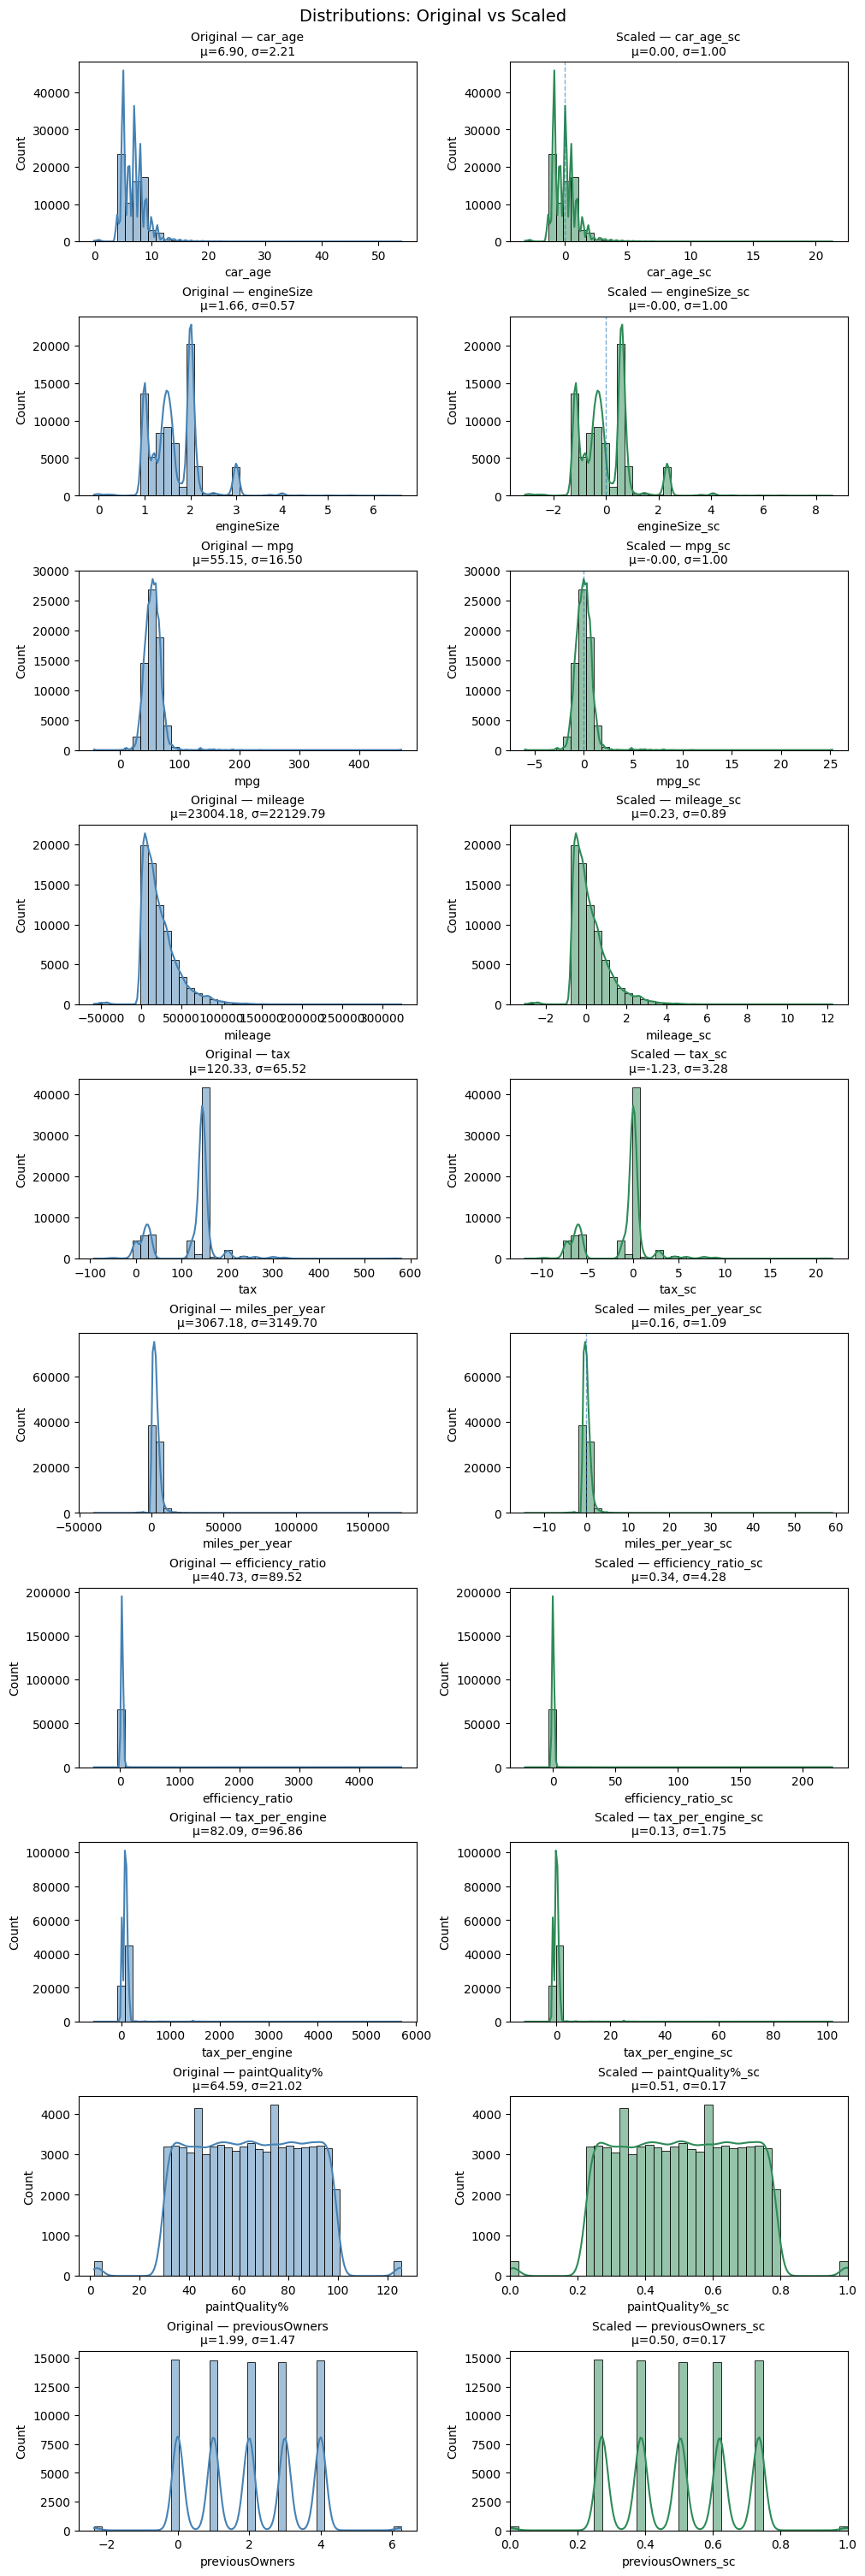

In [55]:
# find all scaled features and their originals
scaled_cols = [c for c in train_sc.columns if c.endswith('_sc')]
pairs = [(c.replace('_sc', ''), c) for c in scaled_cols if c.replace('_sc', '') in train_sc.columns]

if not pairs:
    raise ValueError("No original-scaled pairs found. Make sure to run scale_all_features first.")

ncols = 2
nrows = len(pairs)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3*nrows), constrained_layout=True)

for i, (orig, scaled) in enumerate(pairs):
    ax1, ax2 = axes[i] if nrows > 1 else axes
    
    # Original
    s1 = train_sc[orig].replace([np.inf, -np.inf], np.nan).dropna()
    mu1, sd1 = s1.mean(), s1.std()
    sns.histplot(s1, bins=40, kde=True, color='steelblue', ax=ax1)
    ax1.set_title(f"Original — {orig}\nμ={mu1:.2f}, σ={sd1:.2f}", fontsize=10)
    
    # Scaled
    s2 = train_sc[scaled].replace([np.inf, -np.inf], np.nan).dropna()
    mu2, sd2 = s2.mean(), s2.std()
    sns.histplot(s2, bins=40, kde=True, color='seagreen', ax=ax2)
    ax2.set_title(f"Scaled — {scaled}\nμ={mu2:.2f}, σ={sd2:.2f}", fontsize=10)
    
    # Clamp 0–1 for MinMax-scaled features
    if s2.min() >= -0.05 and s2.max() <= 1.05:
        ax2.set_xlim(0, 1)
    # Draw zero line for standardized features
    if abs(mu2) < 0.2 and 0.7 < sd2 < 1.3:
        ax2.axvline(0, ls='--', lw=1, alpha=0.6)

plt.suptitle("Distributions: Original vs Scaled", fontsize=14)
plt.show()


### 1.8. Feature selection 

Univariate Selection

In [56]:
missing_values = train.isna().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

efficiency_ratio_sc    9294
efficiency_ratio       9294
tax_per_engine         9273
tax_per_engine_sc      9273
mpg_sc                 7926
mpg                    7926
tax                    7904
tax_sc                 7904
miles_per_year         2932
miles_per_year_sc      2932
previousOwners_sc      1550
previousOwners         1550
hasDamage              1548
paintQuality%_sc       1524
condition_score_sc     1524
condition_score        1524
paintQuality%          1524
engineSize_sc          1516
engineSize             1516
car_age_sc             1491
car_age_bin            1491
car_age                1491
year                   1491
mileage_sc             1463
mileage                1463
dtype: int64


# FEATURE SELECTION

In [57]:
def drop_highly_correlated_features(train: pd.DataFrame,
                                    target_col: str = 'price',
                                    corr_threshold: float = 0.95):

    # Select numeric columns (excluding the target)
    num_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c != target_col]
    print(f"\n Number of numeric columns considered: {len(num_cols)}")

    # Correlation matrix
    corr_matrix = train[num_cols].corr()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # |correlation| with the target
    target_corr = train[num_cols + [target_col]].corr()[target_col].abs()

    to_drop = []
    print("\n--- Checking for high correlations ---")
    for col in upper.columns:
        correlated_with = upper.index[(upper[col] >= corr_threshold) | (upper[col] <= -corr_threshold)].tolist()
        for other in correlated_with:
            if other in to_drop or col in to_drop:
                continue

            corr_value = upper.loc[other, col]
            col_tc   = target_corr[col]
            other_tc = target_corr[other]

            if np.isclose(col_tc, other_tc, atol=1e-12):
                if col.endswith('_sc') and not other.endswith('_sc'):
                    drop_col = other
                elif other.endswith('_sc') and not col.endswith('_sc'):
                    drop_col = col
                else:
                    drop_col = sorted([col, other])[0]
            else:
                drop_col = other if other_tc < col_tc else col

            print(f" {col} ↔ {other} | correlation = {corr_value:.3f}")
            print(f"    Correlation with target: {col}={col_tc:.3f}, {other}={other_tc:.3f}")
            print(f"    → REMOVE {drop_col}")
            to_drop.append(drop_col)

    to_drop = sorted(set(to_drop))
    train_reduced = train.drop(columns=to_drop, errors='ignore')

    print("\n--- Final Summary ---")
    print(f"Features removed for |correlation| ≥ {corr_threshold}: {to_drop}")
    print(f"Original shape: {train.shape} → Reduced shape: {train_reduced.shape}")

    return train_reduced, to_drop

In [58]:
# Feature Selection Comparison Function (auto-drop weak features)

def feature_selection_comparison(train: pd.DataFrame,
                                 target_col: str = 'price',
                                 n_features_rfe: int = 14,
                                 random_state: int = 42,
                                 mi_threshold: float = 0.02,
                                 encode_categoricals: bool = False,
                                 verbose: bool = True):
    """
    Compara ANOVA F-test, Mutual Information e RFE (Ridge) e remove 'weak features'.
    Assume que os dados já vêm codificados (one-hot). Converte bool/UInt para float.
    """
    from sklearn.preprocessing import LabelEncoder

    df = train.copy()
    y = df[target_col].values
    X_df = df.drop(columns=[target_col])

    # 1) Normalizar tipos:
    #    - bool/BooleanDtype → int8
    #    - inteiros "nullable" (UInt*) → int64
    #    - resto deixa estar; no fim força para float
    import pandas.api.types as ptypes
    for c in X_df.columns:
        s = X_df[c]
        if ptypes.is_bool_dtype(s):
            X_df[c] = s.astype('int8')
        elif ptypes.is_unsigned_integer_dtype(s):
            X_df[c] = s.astype('int64')
        # (se for object/category e o utilizador permitir, faz LabelEncode)
        elif not ptypes.is_numeric_dtype(s):
            if encode_categoricals:
                X_df[c] = LabelEncoder().fit_transform(s.astype(str))
            else:
                # adia o erro para depois de tentar cast global
                pass

    # 2) Tentativa de cast global para float (garante compatibilidade com sklearn)
    try:
        X = X_df.astype(float).to_numpy(copy=False)
    except Exception:
        non_num = [c for c in X_df.columns if not ptypes.is_numeric_dtype(X_df[c])]
        raise ValueError(
            f"As colunas {non_num} não são numéricas; ativa encode_categoricals=True "
            f"ou faz one-hot antes de chamar feature_selection_comparison."
        )

    feat_names = X_df.columns

    # 3) ANOVA
    F_vals, p_vals = f_regression(X, y)
    anova_df = pd.DataFrame({'Feature': feat_names, 'ANOVA_F': F_vals, 'ANOVA_pvalue': p_vals})

    # 4) Mutual Information
    mi_vals = mutual_info_regression(X, y, random_state=random_state)
    mi_df = pd.DataFrame({'Feature': feat_names, 'Mutual_Info': mi_vals})

    # 5) RFE (Ridge)
    n_sel = max(1, min(n_features_rfe, X.shape[1]-1)) if X.shape[1] > 1 else 1
    rfe = RFE(Ridge(alpha=1.0, random_state=random_state), n_features_to_select=n_sel, step=0.1)
    rfe.fit(X, y)
    rfe_df = pd.DataFrame({'Feature': feat_names, 'RFE_Selected': rfe.support_, 'RFE_Rank': rfe.ranking_})

    # 6) Merge e consenso
    comparison_df = (
        anova_df.merge(mi_df, on='Feature')
                .merge(rfe_df, on='Feature')
                .sort_values(by='ANOVA_F', ascending=False)
                .reset_index(drop=True)
    )
    comparison_df['Consensus'] = comparison_df['RFE_Selected'] | (comparison_df['ANOVA_pvalue'] < 0.05)

    # 7) Weak = falha nas 3 frentes
    weak_features = comparison_df[
        (comparison_df['ANOVA_pvalue'] > 0.05) &
        (~comparison_df['RFE_Selected']) &
        (comparison_df['Mutual_Info'] < mi_threshold)
    ]['Feature'].tolist()

    dropped_weak = sorted(set(weak_features))
    train_reduced = df.drop(columns=dropped_weak, errors='ignore')

    if verbose:
        print("\nFeature Selection (pós-encoding/scaling)")
        print(f"Total de features avaliadas: {X.shape[1]}")
        print(f"RFE n_selected = {n_sel}")
        print(f"Dropped (weak): {len(dropped_weak)}")
        if dropped_weak:
            print(dropped_weak)

    return comparison_df, train_reduced, dropped_weak

## Model

- For this project, we are working on a supervised machine learnig problem, in particular a regression problem. 
- We are trying to create a predictive model for the car value and our target variable is `price` which is a continuous numerical variable. 
- Some of the possible algorithms to aplly in this type of problems are Linear Regression, K-Nearest Neighbors, Support Vector Machines, Decision Tree Regressor or Ensemble Mothods, such as Random Forest Regressor or Gradient Boosting Regressor.

Our first model will be the Random Forest (Regressor).

- The main reason we chose this model is because it is an ensemble algorithm, meaning it combines the predictions of multiple decision trees to create a more robust and accurate final model.

- As the name suggests, it builds a forest, which from a technical point of view refers to constructing a large set of individual decision trees.
This model consists of training many decision trees and combining their predictions.

- The other component of the name (“Random”) introduces randomness into the algorithm to ensure that all trees are different and do not make the same mistakes. To introduce this randomness, the algorithm uses two techniques: bagging (each tree is trained on a different random sample of the training data) and feature randomness (when the algorithm determines how to split the nodes, each tree only has access to a random subset of the total features).

- To provide the final prediction, the Random Forest takes the average of the results from the individual trees.

## Cross Validation Strategy: Kfold 
- We chose this strategy because our training dataset is limited and using another approach could lead to losing part of the data. 

- The K-Fold approach ensures that every data point in the dataset is used for both training and testing. The data is divided into k equal parts (called folds). In each iteration, the model is trained on k–1 folds and tested on the remaining one. This process is repeated k times, changing the test fold in each round.



In [59]:
SEED = 42
# ------------------------------------------
# 0) Helpers de avaliação e de alinhamento
# ------------------------------------------
rng  = np.random.default_rng(SEED)

# Simple metric wrappers returning plain floats
def rmse(y_true, y_pred): return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def mae (y_true, y_pred): return float(mean_absolute_error(y_true, y_pred))
def r2  (y_true, y_pred): return float(r2_score(y_true, y_pred))

def align_like(X_to_align: pd.DataFrame, X_ref: pd.DataFrame) -> pd.DataFrame:
    """Reindex X_to_align to match X_ref columns; missing cols filled with 0 to keep shape consistent."""
    return X_to_align.reindex(columns=X_ref.columns, fill_value=0)

#  BRAND
def fit_brand_stats(X_tr, valid_brands, brand_col='Brand', model_col='model', year_col='year'):
    Xt = X_tr.copy()
    # Normalize brand text and fill missing
    Xt[brand_col] = Xt[brand_col].fillna('UNKNOWN').astype(str).str.upper().str.strip()

    # First: substring-based corrections for invalid brands
    invalids = sorted([b for b in Xt[brand_col].unique() if b not in valid_brands], key=len)
    _, substr_corr, remaining = correct_invalid_brands_in_df(Xt, brand_col, valid_brands, invalids)
    Xt[brand_col] = Xt[brand_col].replace(substr_corr)

    # Second: resolve ambiguous brands using model/year context
    Xt2, corrections2, still = correct_ambiguous_brands(
        Xt, brand_col, valid_brands, remaining, model_col=model_col, year_col=year_col
    )

    # Aggregate modes to use as fallbacks
    valid_mask = Xt2[brand_col].isin(valid_brands)
    global_mode = Xt2.loc[valid_mask, brand_col].value_counts().index[0] if valid_mask.any() else None

    # Per-year most frequent brand (used when year is informative)
    year_mode = {}
    if year_col in Xt2.columns:
        tmp = Xt2.loc[valid_mask, [year_col, brand_col]].value_counts().reset_index(name='n')
        for yv, grp in tmp.groupby(year_col):
            year_mode[yv] = grp.sort_values('n', ascending=False)[brand_col].iloc[0]

    # Per-model brand frequency table (to resolve by model)
    model_counts = {}
    if model_col in Xt2.columns:
        tmpm = Xt2.loc[valid_mask, [model_col, brand_col]].value_counts().reset_index(name='n')
        for m, grp in tmpm.groupby(model_col):
            s = grp.set_index(brand_col)['n'].sort_values(ascending=False)
            model_counts[m] = s

    # Map invalid tokens to chosen replacements 
    invalid_to_choice = {}
    for k, v in corrections2.items():
        inv = k[0] if isinstance(k, tuple) else k
        invalid_to_choice.setdefault(inv, v)

    # Persist everything needed to reproduce fixes on validation/test
    stats = {
        'substr_corr': substr_corr,
        'invalid_to_choice': invalid_to_choice,
        'global_mode': global_mode,
        'year_mode': year_mode,
        'model_counts': model_counts
    }
    return Xt2, stats

def apply_brand_stats(X_va, stats, valid_brands, brand_col='Brand', model_col='model', year_col='year'):
    # Same normalization as training
    Xv = X_va.copy()
    Xv[brand_col] = Xv[brand_col].fillna('UNKNOWN').astype(str).str.upper().str.strip()

    # Apply substring corrections learned in training
    if stats['substr_corr']:
        Xv[brand_col] = Xv[brand_col].replace(stats['substr_corr'])

    valid_set = set(valid_brands)

    # Row-wise - prioritize exact validity, learned mappings, then model/year/global fallbacks
    def _fix(row):
        b = row[brand_col]
        if b in valid_set or b == 'UNKNOWN':
            return b
        if b in stats['invalid_to_choice']:
            return stats['invalid_to_choice'][b]
        m = row.get(model_col, None)
        if m in stats['model_counts'] and len(stats['model_counts'][m]) > 0:
            return stats['model_counts'][m].index[0]
        yv = row.get(year_col, None)
        if pd.notna(yv) and yv in stats['year_mode']:
            return stats['year_mode'][yv]
        return stats['global_mode'] if stats['global_mode'] is not None else b

    Xv[brand_col] = Xv.apply(_fix, axis=1)
    return Xv

# 2) MODELS/FUEL/TRANSMISSION
def learn_and_apply_models(X_tr, X_va, valid_models_by_brand):
    Xt = X_tr.copy()
    Xt, model_corr = correct_invalid_models(Xt, valid_models_by_brand)

    apply_map = {}
    for k, v in model_corr.items():
        inv = k.split('_')[0] if isinstance(k, str) else (k[0] if isinstance(k, tuple) else k)
        apply_map[inv] = v

    Xv = X_va.copy()
    if 'model' in Xv.columns:
        mask = Xv['model'].isin(apply_map.keys())
        Xv.loc[mask, 'model'] = Xv.loc[mask, 'model'].map(apply_map).fillna(Xv.loc[mask, 'model'])
    return Xt, Xv

def learn_and_apply_fuel(X_tr, X_va, valid_fueltypes):
    Xt = X_tr.copy()
    Xt, fuel_corr = correct_invalid_fueltypes(Xt, valid_fueltypes)

    # Build simple mapping from possibly composite keys to replacement value
    apply_map = {}
    for k, v in fuel_corr.items():
        inv = k.split('_')[0] if isinstance(k, str) else (k[0] if isinstance(k, tuple) else k)
        apply_map[inv] = v

    Xv = X_va.copy()
    if 'fuelType' in Xv.columns:
        mask = Xv['fuelType'].isin(apply_map.keys())
        Xv.loc[mask, 'fuelType'] = Xv.loc[mask, 'fuelType'].map(apply_map).fillna(Xv.loc[mask, 'fuelType'])
    return Xt, Xv

def learn_and_apply_transmission(X_tr, X_va, valid_transmissions):
    Xt = X_tr.copy()
    Xt, trans_corr = correct_invalid_transmissions(Xt, valid_transmissions)

    apply_map = {}
    for k, v in trans_corr.items():
        inv = k.split('_')[0] if isinstance(k, str) else (k[0] if isinstance(k, tuple) else k)
        apply_map[inv] = v

    Xv = X_va.copy()
    if 'transmission' in Xv.columns:
        mask = Xv['transmission'].isin(apply_map.keys())
        Xv.loc[mask, 'transmission'] = Xv.loc[mask, 'transmission'].map(apply_map).fillna(Xv.loc[mask, 'transmission'])
    return Xt, Xv

# 3) NUMERICAL (train->val)

def apply_numeric_preprocess_all(X_tr, X_va):
    Xt, Xv = X_tr.copy(), X_va.copy()
    Xt, Xv = drop_hasDamage(Xt, Xv)
    Xt, Xv = preprocess_year(Xt, Xv, max_valid_year=2020)
    Xt, Xv = preprocess_paintQuality(Xt, Xv)
    Xt, Xv = preprocess_mileage(Xt, Xv)
    Xt, Xv = preprocess_tax(Xt, Xv)
    Xt, Xv = preprocess_mpg(Xt, Xv)
    Xt, Xv = preprocess_engineSize(Xt, Xv)
    Xt, Xv = preprocess_previousOwners(Xt, Xv) # last because depends on other columns 

    return Xt, Xv



## Pipeline

In [60]:
#  K-FOLD PIPELINE 


SEED = 42
TARGET = 'price'
ID_COL  = 'carID'

# Split out features/target from the full training frame.
# We also drop any ID column so it never leaks into the model.
X_all_raw = train.drop(columns=[TARGET] + ([ID_COL] if ID_COL in train.columns else [])).copy()
y_all     = train[TARGET].astype(float).copy()

# 5-fold CV with shuffle 
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_metrics = [] # We’ll store per-fold metrics so you can later compare

# ---------------------------------------------------------
# Main CV loop: for each fold we:
#   1) split into train/val indices
#   2) run preprocessing/feature engineering
#   3) scale, one-hot - this part is still in deleopment, align columns
#   4) run feature selection (ANOVA/MI/RFE)
#   5) drop highly correlated scaled numerics
#   6) fit/score the models (RF + OLS)
# ---------------------------------------------------------
for fold, (tr, va) in enumerate(kf.split(X_all_raw), start=1):
    X_tr_raw, X_va_raw = X_all_raw.iloc[tr].copy(), X_all_raw.iloc[va].copy() # Subset the  matrices according to the fold indices
    y_tr,     y_va     = y_all.iloc[tr], y_all.iloc[va]

    # BRANDS
    X_tr_b, brand_stats = fit_brand_stats(X_tr_raw, valid_brands, brand_col='Brand', model_col='model', year_col='year')
    X_va_b              = apply_brand_stats(X_va_raw,  brand_stats,  valid_brands, brand_col='Brand', model_col='model', year_col='year')

    # MODELS
    X_tr_m, X_va_m = learn_and_apply_models(X_tr_b, X_va_b, valid_models)

    # FUEL
    X_tr_f, X_va_f = learn_and_apply_fuel(X_tr_m, X_va_m, valid_fueltypes)

    # TRANSMISSION
    X_tr_t, X_va_t = learn_and_apply_transmission(X_tr_f, X_va_f, valid_transmissions)

    # Numericals
    X_tr_n, X_va_n = apply_numeric_preprocess_all(X_tr_t, X_va_t)

    # DERIVED FEATURES
    X_tr_n = add_derived_features(X_tr_n, ref_year=2020)
    X_va_n = add_derived_features(X_va_n, ref_year=2020)

    # just in case: substituir infs por NaN
    for df in (X_tr_n, X_va_n):
        numcols = df.select_dtypes(include='number').columns
        df[numcols] = df[numcols].replace([np.inf, -np.inf], np.nan)

    # IMPUTATION
    # Median imputation learned on the TRAIN SPLIT ONLY, applied to both
    # train and val. Columns grouped by scaling strategy 
    to_impute_std = [c for c in ['car_age','engineSize','mpg'] if c in X_tr_n.columns]
    to_impute_rob = [c for c in ['mileage','tax','miles_per_year','efficiency_ratio','tax_per_engine'] if c in X_tr_n.columns]
    to_impute_mm  = [c for c in ['paintQuality%','previousOwners','condition_score'] if c in X_tr_n.columns]
    for c in (to_impute_std + to_impute_rob + to_impute_mm):
        med = X_tr_n[c].median(skipna=True)
        X_tr_n[c] = X_tr_n[c].fillna(med)
        X_va_n[c] = X_va_n[c].fillna(med)

    # SCALING with our function
    X_tr_n, X_va_n, fold_scalers = scale_all_features(X_tr_n, X_va_n)

    # ficar só com *_sc para evitar duplicados
    KEEP_ONLY_SCALED = True
    if KEEP_ONLY_SCALED and fold_scalers:
        src_cols = []
        for name in ('standard','robust','minmax'):
            if name in fold_scalers:
                src_cols += fold_scalers[name][0] # original columns that got scaled
        if src_cols:
            X_tr_n.drop(columns=[c for c in src_cols if c in X_tr_n.columns], inplace=True)
            X_va_n.drop(columns=[c for c in src_cols if c in X_va_n.columns], inplace=True)

    # ENCODING 
    # One-hot encode remaining categoricals 
    # then align validation to training columns (missing to 0)
    X_tr_1h = pd.get_dummies(X_tr_n, drop_first=False, dummy_na=False)
    X_va_1h = pd.get_dummies(X_va_n, drop_first=False, dummy_na=False)
    X_va_1h = align_like(X_va_1h, X_tr_1h)

    # FEATURE SELECTION (post-scaling + one-hot)
    # We build a train-only dataframe with the target, run the
    # selection routine (ANOVA/MI/RFE), and drop weak features.
    # encode_categoricals=False because everything is numeric now.
    fs_train = X_tr_1h.copy()
    fs_train[TARGET] = y_tr.values

    n_rfe = max(1, min(50, max(1, X_tr_1h.shape[1] // 3)))  # ~1/3 com limites
    fs_summary, fs_train_reduced, dropped_weak = feature_selection_comparison(
        fs_train,
        target_col=TARGET,
        n_features_rfe=n_rfe,
        mi_threshold=0.02,
        encode_categoricals=False,  # already numeric 
        verbose=True
    )

    # Apply the same column drop to train/val design matrices to keep them aligned
    cols_keep = [c for c in X_tr_1h.columns if c not in dropped_weak]
    X_tr = X_tr_1h[cols_keep].copy()
    X_va = X_va_1h[cols_keep].copy()

    # correlation pruning (only for scaled continuous *_sc)
    # We avoid touching one-hot dummies here to keep interpretability of
    # categoricals; only almot duplicates among scaled numerics 
    sc_cols = [c for c in X_tr.columns if c.endswith('_sc')]
    if len(sc_cols) > 1:
        # Builds a small frame with just scaled numerics + target for correlation checks
        tmp_num = pd.concat([X_tr[sc_cols], y_tr.reset_index(drop=True)], axis=1)
        tmp_num.columns = sc_cols + [TARGET]
        # This returns a reduced matrix (columns kept) and the list of dropped ones
        tmp_num_reduced, dropped_corr = drop_highly_correlated_features(
            tmp_num, target_col=TARGET, corr_threshold=0.95
        )
        # Compute which *_sc columns were removed and reflect that in X_tr/X_va
        drop_corr_cols = [c for c in sc_cols if c not in tmp_num_reduced.columns]
        if drop_corr_cols:
            X_tr.drop(columns=drop_corr_cols, inplace=True)
            X_va.drop(columns=drop_corr_cols, inplace=True, errors='ignore')
            print(f"[FS-corr] Removidas (alta corr): {len(drop_corr_cols)} → {drop_corr_cols}")

    # MODELOS: RandomForest + OLS
    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=600, max_depth=40, min_samples_split=2, min_samples_leaf=1,
            max_features=0.7, bootstrap=True, random_state=SEED, n_jobs=-1
        ),
        "OLS": LinearRegression()
    }

    # Fit and evaluate each model on the current validation split.
    for name, mdl in models.items():
        mdl.fit(X_tr, y_tr)
        pred = mdl.predict(X_va)

        # Percent metrics use clipping for zero division safety.
        eps   = 1e-6
        mape  = float(np.mean(np.abs((y_va - pred) / np.clip(np.abs(y_va), eps, None))) * 100)
        mdape = float(np.median(np.abs((y_va - pred) / np.clip(np.abs(y_va), eps, None))) * 100)

        # Store metrics
        m = {
            'fold':  fold,
            'model': name,
            'rmse':  float(np.sqrt(mean_squared_error(y_va, pred))),
            'mae':   float(mean_absolute_error(y_va, pred)),
            'r2':    float(r2_score(y_va, pred)),
            'mape':  mape,
            'mdape': mdape
        }

        #fold log
        print(
            f"[{name}] Fold {fold}: RMSE={m['rmse']:.1f} | MAE={m['mae']:.1f} | "
            f"MAPE={m['mape']:.2f}% | MdAPE={m['mdape']:.2f}% | R²={m['r2']:.4f}"
        )
        fold_metrics.append(m)



Feature Selection (pós-encoding/scaling)
Total de features avaliadas: 212
RFE n_selected = 50
Dropped (weak): 33
['Brand_VW', 'fuelType_ELECTRIC', 'fuelType_OTHER', 'model_200', 'model_230', 'model_AMPERA', 'model_CADDY LIFE', 'model_CADDY MAXI LIFE', 'model_CASCADA', 'model_COMBO LIFE', 'model_ESCORT', 'model_GALAXY', 'model_GOLF', 'model_GOLF SV', 'model_GRAND TOURNEO CONNECT', 'model_GRANDLAND X', 'model_GT86', 'model_I3', 'model_I800', 'model_IQ', 'model_KADJAR', 'model_KONA', 'model_PASSAT', 'model_RANGER', 'model_S-MAX', 'model_SCALA', 'model_TERRACAN', 'model_TOURAN', 'model_VELOSTE', 'model_VERSO-S', 'model_VIVARO', 'paintQuality%_sc', 'transmission_OTHER']

 Number of numeric columns considered: 10

--- Checking for high correlations ---

--- Final Summary ---
Features removed for |correlation| ≥ 0.95: []
Original shape: (72963, 11) → Reduced shape: (72963, 11)
[RandomForest] Fold 1: RMSE=2246.4 | MAE=1379.3 | MAPE=8.89% | MdAPE=6.05% | R²=0.9446
[OLS] Fold 1: RMSE=3817.4 | M

In [61]:
# === FINAL TRAIN (full) + PREDICT ON TEST 
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

SEED = 42
TARGET = "price"
ID_COL = "carID"
MODEL_NAME = "RandomForest"   # ou "OLS" muda-se modleo aqui
KEEP_ONLY_SCALED = True

# separar X/y e garantir que test está carregado
X_full_raw = train.drop(columns=[TARGET] + ([ID_COL] if ID_COL in train.columns else [])).copy()
y_full     = train[TARGET].astype(float).copy()



X_test_raw = test.drop(columns=[ID_COL] if ID_COL in test.columns else [], errors='ignore').copy()

# BRANDS (fit no train inteiro - aplica ao test)
X_tr_b, brand_stats = fit_brand_stats(X_full_raw, valid_brands, brand_col='Brand', model_col='model', year_col='year')
X_te_b              = apply_brand_stats(X_test_raw, brand_stats, valid_brands, brand_col='Brand', model_col='model', year_col='year')

# MODELS / FUEL / TRANSMISSION
X_tr_m, X_te_m = learn_and_apply_models(X_tr_b, X_te_b, valid_models)
X_tr_f, X_te_f = learn_and_apply_fuel  (X_tr_m, X_te_m, valid_fueltypes)
X_tr_t, X_te_t = learn_and_apply_transmission(X_tr_f, X_te_f, valid_transmissions)

# NUMÉRICOS (pré-process)
X_tr_n, X_te_n = apply_numeric_preprocess_all(X_tr_t, X_te_t)

# DERIVED FEATURES 
X_tr_n = add_derived_features(X_tr_n, ref_year=2020)
X_te_n = add_derived_features(X_te_n, ref_year=2020)

# limpar inf - NaN (antes de imputar)
for df_ in (X_tr_n, X_te_n):
    numcols = df_.select_dtypes(include='number').columns
    df_[numcols] = df_[numcols].replace([np.inf, -np.inf], np.nan)

# IMPUTAÇÃO nas colunas a escalar (medians do train)
to_std = [c for c in ['car_age','engineSize','mpg'] if c in X_tr_n.columns]
to_rob = [c for c in ['mileage','tax','miles_per_year','efficiency_ratio','tax_per_engine'] if c in X_tr_n.columns]
to_mm  = [c for c in ['paintQuality%','previousOwners','condition_score'] if c in X_tr_n.columns]
for c in (to_std + to_rob + to_mm):
    med = X_tr_n[c].median(skipna=True)
    X_tr_n[c] = X_tr_n[c].fillna(med)
    X_te_n[c] = X_te_n[c].fillna(med)

#SCALING 
X_tr_n, X_te_n, full_scalers = scale_all_features(X_tr_n, X_te_n)

#  manter só *_sc
if KEEP_ONLY_SCALED and full_scalers:
    src_cols = []
    for name in ('standard','robust','minmax'):
        if name in full_scalers:
            src_cols += full_scalers[name][0]
    if src_cols:
        X_tr_n.drop(columns=[c for c in src_cols if c in X_tr_n.columns], inplace=True)
        X_te_n.drop(columns=[c for c in src_cols if c in X_te_n.columns], inplace=True)

# dtype=float para evitar dtypes "não totalmente numéricos"
X_tr_1h = pd.get_dummies(X_tr_n, drop_first=False, dummy_na=False, dtype=float)
X_te_1h = pd.get_dummies(X_te_n, drop_first=False, dummy_na=False, dtype=float)
X_te_1h = align_like(X_te_1h, X_tr_1h)

# FEATURE SELECTION 
fs_train = X_tr_1h.copy()
fs_train[TARGET] = y_full.values

n_rfe = max(1, min(50, max(1, X_tr_1h.shape[1] // 3)))  # ~1/3 com bounds 
fs_summary, fs_train_reduced, dropped_weak = feature_selection_comparison(
    fs_train,
    target_col=TARGET,
    n_features_rfe=n_rfe,
    mi_threshold=0.02,
    encode_categoricals=False, 
    verbose=True
)

# pruning
cols_keep = [c for c in X_tr_1h.columns if c not in dropped_weak]
X_tr_fs = X_tr_1h[cols_keep].copy()
X_te_fs = X_te_1h[cols_keep].copy()

# 
sc_cols = [c for c in cols_keep if c.endswith('_sc')]
if len(sc_cols) > 1:
    tmp_num = pd.concat([X_tr_fs[sc_cols], y_full.reset_index(drop=True)], axis=1)
    tmp_num.columns = sc_cols + [TARGET]
    tmp_num_reduced, dropped_corr = drop_highly_correlated_features(
        tmp_num, target_col=TARGET, corr_threshold=0.95
    )
    drop_corr_cols = [c for c in sc_cols if c not in tmp_num_reduced.columns]
    if drop_corr_cols:
        X_tr_fs.drop(columns=drop_corr_cols, inplace=True)
        X_te_fs.drop(columns=drop_corr_cols, inplace=True, errors='ignore')

# 6) Final Model
if MODEL_NAME == "RandomForest":
    model = RandomForestRegressor(
        n_estimators=600, max_depth=40, min_samples_split=2, min_samples_leaf=1,
        max_features=0.7, bootstrap=True, random_state=SEED, n_jobs=-1
    )
elif MODEL_NAME == "OLS":
    model = LinearRegression()
else:
    raise ValueError("MODEL_NAME must be 'RandomForest' or 'OLS'.")

model.fit(X_tr_fs, y_full)
test_pred = model.predict(X_te_fs)

# avoid negative prices
test_pred = np.maximum(test_pred, 0)

# obtain submission dataframe
sub = pd.DataFrame({
    "carID": test[ID_COL].values if ID_COL in test.columns else np.arange(len(test_pred)),
    "price": np.round(test_pred).astype(int)
})

print(sub.head(10).to_csv(index=False, header=True).strip())
# Save
sub.to_csv("submission.csv", index=False)
print("\n Saved as 'submission.csv'")



Feature Selection (pós-encoding/scaling)
Total de features avaliadas: 215
RFE n_selected = 50
Dropped (weak): 34
['Brand_VW', 'fuelType_ELECTRIC', 'fuelType_OTHER', 'model_200', 'model_220', 'model_230', 'model_ACCENT', 'model_AMPERA', 'model_CADDY LIFE', 'model_CADDY MAXI LIFE', 'model_CASCADA', 'model_COMBO LIFE', 'model_ESCORT', 'model_FOX', 'model_GALAXY', 'model_GOLF', 'model_GOLF SV', 'model_GRAND TOURNEO CONNECT', 'model_GRANDLAND X', 'model_GT86', 'model_I3', 'model_I800', 'model_KADJAR', 'model_KONA', 'model_PASSAT', 'model_RANGER', 'model_S-MAX', 'model_SCALA', 'model_TERRACAN', 'model_TOURAN', 'model_VELOSTE', 'model_VIVARO', 'paintQuality%_sc', 'transmission_OTHER']

 Number of numeric columns considered: 10

--- Checking for high correlations ---

--- Final Summary ---
Features removed for |correlation| ≥ 0.95: []
Original shape: (75973, 11) → Reduced shape: (75973, 11)
carID,price
89856,20856
106581,21352
80886,14268
100174,19196
81376,24583
85391,12035
82175,14800
95250